# Introduction to vector databases on S&P 500 news

 # 📌 Objectives

 By the end of this notebook, students will be able to:

 1. **Load and Explore Financial News Data:**
    - Load a preprocessed dataset of financial news headlines and summaries related to S&P 500 companies.
    - Inspect and structure relevant metadata including publication date, ticker, and provider.

 2. **Build a Custom Vector Store:**
    - Combine title and summary text for embedding.
    - Implement a vector store from scratch with support for semantic search and optional metadata-based filtering using cosine similarity.

 3. **Generate and Use Sentence Embeddings:**
    - Apply a pre-trained transformer model (all-MiniLM-L6-v2) to encode text into embeddings for semantic analysis.

 4. **Perform Semantic Search with Filtering:**
    - Retrieve the most relevant news documents for a given query using both full-dataset and metadata-filtered searches.

 5. **Analyze Semantic Search Results:**
    - Interpret and visualize results of search queries (e.g., "AI announcement").
    - Identify temporal patterns and ticker frequency among top-ranked results.

 6. **Implement a FAISS-Based Vector Store:**
    - Normalize embeddings and use FAISS (IndexFlatIP) to enable efficient similarity search at scale.
    - Compare FAISS-based search results with custom vector store results.

 7. **Critically Compare Search Systems:**
    - Evaluate differences in similarity computation, speed, and scalability between custom and FAISS-based systems.
    - Reflect on design trade-offs for real-world vector search systems.

## Install and Import important librairies

In [1]:
%pip install sentence-transformers
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load news data

Load the provided news dataset and inspect the contents.

 👉 **Instructions**:
 - Load the CSV file named df_news.csv into a pandas DataFrame.
 - Convert the PUBLICATION_DATE column to a proper date format (not datetime).
 - Display the first few rows to understand the data structure. The key columns you’ll be using are:
   - TITLE
   - SUMMARY
   - TICKER
   - PROVIDER
   - PUBLICATION_DATE


In [4]:
df_news = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fintech/df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


## Implement custom vector store

You will now implement a basic vector store from scratch. This class will allow you to:
1. Store embedded text and metadata.
2. Perform filtered semantic search using cosine similarity.

 👉 **Instructions**:

### Step 1: Prepare Documents
 - Combine the TITLE and SUMMARY columns into a single column named EMBEDDED_TEXT.
 - This combined text will be embedded later.

### Step 2: Load Embedding Model
 - Load the 'all-MiniLM-L6-v2' model from sentence-transformers.

### Step 3: Define CustomVectorStore Class
 Implement the class with the following methods (functions):

 - '__init__': Accepts an embedding model, list of documents, and corresponding metadata. Computes and stores embeddings for all documents.
 - search: Takes a query and returns the top k most similar documents, optionally filtered using metadata.
   - If a metadata_filter function is provided, apply it before computing similarity.
   - Use cosine similarity to compute distances.
   - Return the top k results as tuples of: (document, metadata, similarity score).

 ✅ **Requirements**:
 - Ensure the number of documents matches the number of metadata entries.
 - Make use of sklearn.metrics.pairwise.cosine_similarity.

You will test your class at the end.

In [5]:
# CODE HERE
# Use as many coding cells as you need
df_news['EMBEDDED_TEXT']=df_news['TITLE']+df_news['SUMMARY']
df_news.head(5)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL,EMBEDDED_TEXT
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...,2 Dow Jones Stocks with Promising Prospects an...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...,3 S&P 500 Stocks Skating on Thin IceThe S&P 50...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...,3M Rises 15.8% YTD: Should You Buy the Stock N...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...,3 Cash-Producing Stocks with Questionable Fund...


In [6]:
appl_df=df_news[df_news['TICKER']=='AAPL']
appl_df

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL,EMBEDDED_TEXT
371,AAPL,Elon Musk's renewed 'laser focus' on Tesla is ...,Elon Musk is back at Tesla (TSLA) after servin...,2025-05-30,Yahoo Finance Video,https://finance.yahoo.com/video/elon-musks-ren...,Elon Musk's renewed 'laser focus' on Tesla is ...
372,AAPL,The fate of Google's search empire is now up t...,Google will have to wait for a US judge to dec...,2025-05-30,Yahoo Finance,https://finance.yahoo.com/news/the-fate-of-goo...,The fate of Google's search empire is now up t...
373,AAPL,Best Stock to Buy Right Now: Apple vs. Chipotle,Chipotle has had more consistent annual growth...,2025-05-31,Motley Fool,https://www.fool.com/investing/2025/05/31/best...,Best Stock to Buy Right Now: Apple vs. Chipotl...
374,AAPL,Where the Stock Market Stands Now After a Wild...,(Bloomberg) -- The stock market’s crazy first ...,2025-05-31,Bloomberg,https://finance.yahoo.com/news/where-stock-mar...,Where the Stock Market Stands Now After a Wild...
375,AAPL,47% of Berkshire Hathaway's $276 Billion Warre...,Apple has developed an ecosystem of tech devic...,2025-05-31,Motley Fool,https://www.fool.com/investing/2025/05/31/47-o...,47% of Berkshire Hathaway's $276 Billion Warre...
376,AAPL,These Are Stocks You Should Watch in June,"Stocks soared in May, boosted by easing trade ...",2025-05-31,Investopedia,https://www.investopedia.com/stocks-to-watch-i...,These Are Stocks You Should Watch in JuneStock...
377,AAPL,Warren Buffett Holds Apple Stock Despite Tarif...,Warren Buffett's Berkshire Hathaway continued ...,2025-05-31,Motley Fool,https://www.fool.com/investing/2025/05/31/warr...,Warren Buffett Holds Apple Stock Despite Tarif...
378,AAPL,Trump’s trade war is bruising Apple — and your...,President Donald Trump’s swipes at Apple aren’...,2025-05-31,CNN Business,https://www.cnn.com/2025/05/31/economy/tariffs...,Trump’s trade war is bruising Apple — and your...
379,AAPL,"Judge Weighs Big Changes to Google, Including ...",(Bloomberg) -- The federal judge who will deci...,2025-05-30,Bloomberg,https://finance.yahoo.com/news/google-search-j...,"Judge Weighs Big Changes to Google, Including ..."
380,AAPL,US Smartphone Manufacturing Is a 'Dream': IDC'...,"Smartphone manufacturing in the US is a ""dream...",2025-05-30,Bloomberg,https://finance.yahoo.com/video/us-smartphone-...,US Smartphone Manufacturing Is a 'Dream': IDC'...



## Create and populate the vector store

 👉 **Instructions**:
 - Convert the combined EMBEDDED_TEXT column into a list of strings.
 - Create a metadata list of dictionaries for each document with keys:
   - 'PUBLICATION_DATE'
   - 'TICKER'
   - 'PROVIDER'
 - Instantiate your CustomVectorStore using:
   - The embedding model.
   - The list of document strings.
   - The metadata list.

 After initializing the store, you should be able to perform searches using:
'store.search("Apple earnings", k=3)'


In [7]:
# CODE HERE
# Use as many coding cells as you need
list_strings = df_news['EMBEDDED_TEXT'].tolist()
list_strings

['2 Dow Jones Stocks with Promising Prospects and 1 to AvoidThe Dow Jones (^DJI) is made up of 30 of the most established and influential companies in the market. But even blue-chip stocks can struggle - some are dealing with slowing growth, outdated business models, or increasing competition.',
 '3 S&P 500 Stocks Skating on Thin IceThe S&P 500 (^GSPC) is often seen as a benchmark for strong businesses, but that doesn’t mean every stock is worth owning. Some companies face significant challenges, whether it’s stagnating growth, heavy debt, or disruptive new competitors.',
 '3M Rises 15.8% YTD: Should You Buy the Stock Now or Wait?MMM is making strides in the aerospace, industrial adhesives and tapes, and electrical markets, which makes the stock worth a watch amid certain headwinds.',
 'Q1 Earnings Roundup: 3M (NYSE:MMM) And The Rest Of The General Industrial Machinery SegmentQuarterly earnings results are a good time to check in on a company’s progress, especially compared to its peer

In [8]:
list_dictionaries =[]
for i in range(len(df_news)):
  list_dictionaries.append({
      'PUBLICATION_DATE': df_news['PUBLICATION_DATE'][i],
      'TICKER': df_news['TICKER'][i],
      'PROVIDER': df_news['PROVIDER'][i]})

list_dictionaries

[{'PUBLICATION_DATE': datetime.date(2025, 5, 29),
  'TICKER': 'MMM',
  'PROVIDER': 'StockStory'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 27),
  'TICKER': 'MMM',
  'PROVIDER': 'StockStory'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 22),
  'TICKER': 'MMM',
  'PROVIDER': 'Zacks'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 22),
  'TICKER': 'MMM',
  'PROVIDER': 'StockStory'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 19),
  'TICKER': 'MMM',
  'PROVIDER': 'StockStory'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 15),
  'TICKER': 'MMM',
  'PROVIDER': 'Zacks'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 13),
  'TICKER': 'MMM',
  'PROVIDER': 'GuruFocus.com'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 12),
  'TICKER': 'MMM',
  'PROVIDER': 'StockStory'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 10),
  'TICKER': 'MMM',
  'PROVIDER': 'Motley Fool'},
 {'PUBLICATION_DATE': datetime.date(2025, 5, 8),
  'TICKER': 'MMM',
  'PROVIDER': 'Zacks'},
 {'PUBLICATION_DATE': datetime.d

In [9]:
#Encoding the list_strings
model=SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
 class CustomVectorStore:
    def __init__(self, embedding_model=model, text_encoded=list_strings, metadata_list=list_dictionaries):
        self.embedding_model = embedding_model
        self.embeddings = text_encoded
        self.metadata_list = metadata_list

    def metadata_filter(self, query):
      words = query.lower().split()
      filtered_metadata = []
      for metadata in self.metadata_list:
          values = [str(v).lower() for v in metadata.values()]
          if any(word in val for word in words for val in values):
              filtered_metadata.append(metadata)
      return filtered_metadata

    def search(self, query, k=5):
        #ensuring the number of documents matches the number of metadata entries.
        assert len(self.embeddings) == len(self.metadata_list), "Number of embeddings and metadata entries must match."
        #validate if the metadata_filter function was used for the query
        filtered_metadata = self.metadata_filter(query)
        idx = [i for i, metadata in enumerate(self.metadata_list) if metadata in filtered_metadata]
        if idx:
            filtered_doc = [self.embeddings[i] for i in idx]
            filtered_meta = [self.metadata_list[i] for i in idx]
        else:
            filtered_doc = self.embeddings
            filtered_meta = self.metadata_list
        #embeding query and list of texts
        query_embedding = self.embedding_model.encode([query])
        encode_texts = self.embedding_model.encode(filtered_doc)
        #coisine similarity
        similarities = cosine_similarity(query_embedding, encode_texts)[0]
        #top k
        top_k = np.argsort(similarities)[::-1][:k]
        #return the tupple
        return [(filtered_meta[i], similarities[i], filtered_doc[i]) for i in top_k]


In [11]:
store = CustomVectorStore(model)
store.search("Apple earnings", k=3)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[({'PUBLICATION_DATE': datetime.date(2025, 4, 30),
   'TICKER': 'OKE',
   'PROVIDER': 'Simply Wall St.'},
  np.float32(0.5779574),
  'ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US$8 BillionONEOK (NYSE:OKE) recently released its first-quarter earnings, reporting revenue of USD 8,043 million, a marked increase year-over-year, but a minor dip in net income and earnings per share. Alongside this, the company reaffirmed its quarterly dividend of $1.03 per share. These updates coincide with a 4.5% price increase over the week, which aligns with broader market gains of 5.2%. Despite fluctuations in major indices due to economic data and earnings reports from numerous companies,...'),
 ({'PUBLICATION_DATE': datetime.date(2025, 5, 28),
   'TICKER': 'HUM',
   'PROVIDER': 'Simply Wall St.'},
  np.float32(0.5734036),
  "Humana (NYSE:HUM) Sees Revenue Increase in First-Quarter Earnings to US$32,112 MillionHumana (NYSE:HUM) recently reported first-quarter earnings, showcasing a revenue increa

## Using your vector store and analyzing the results

### Retrieve AI Announcements

 Now that your vector store is working, let's use it to retrieve relevant documents.

 👉 **Instructions**:
 - Perform a semantic search using the query `"AI announcement"` with `k=50` to retrieve the top 50 most relevant articles.
 - Display each result's:
   - `TICKER`
   - `PUBLICATION_DATE`
   - `PROVIDER`
   - Similarity score
   - Full document text


In [12]:
# CODE HERE
# Use as many coding cells as you need
AI_ANN=store.search("AI announcement", k=50)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [13]:
for i in range(len(AI_ANN)):
  print(f"TICKER: {AI_ANN[i][0]['TICKER']}")
  print(f"PUBLICATION_DATE: {AI_ANN[i][0]['PUBLICATION_DATE']}")
  print(f"PROVIDER: {AI_ANN[i][0]['PROVIDER']}")
  print(f"Similarity score: {AI_ANN[i][1]}")
  print(f"Full document text: {AI_ANN[i][2]}")
  print()

TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Similarity score: 0.5567173957824707
Full document text: AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.

TICKER: MSFT
PUBLICATION_DATE: 2025-05-30
PROVIDER: Investor's Business Daily
Similarity score: 0.4089764952659607
Full document text: ServiceNow Regenerates On Swarm Of AI Deals With Amazon, Microsoft And MoreTeaming up with AI giants like Amazon, Microsoft and others, ServiceNow stock has rebounded and stands poised to break out.

TICKER: NOW
PUBLICATION_DATE: 2025-05-30
PROVIDER: Investor's Business Daily
Similarity score: 0.4089764952659607
Full document text: ServiceNow Regenerates On Swarm Of AI Deals With Amazon, Microsoft And MoreTeaming up with AI giants like Amazon, Microsoft and others, ServiceNow stock has rebounded and stands poised to

 ### **Q1.** What are the top companies (by TICKER) most frequently appearing in the top 50 search results for the query "AI announcement"?  
 Check their company names on Yahoo Finance. Are you surprised by the results?

 ✅ **Your task**:
 - Count the number of times each TICKER appears.
 - Print and analyze the top results.

In [14]:
# CODE HERE
# Use as many coding cells as you need
list_tickers=[]
for i in range(len(AI_ANN)):
  list_tickers.append(AI_ANN[i][0]['TICKER'])

list_tickers

['ADBE',
 'MSFT',
 'NOW',
 'CSCO',
 'AMZN',
 'AIG',
 'AIZ',
 'AIG',
 'AVGO',
 'DG',
 'CRWD',
 'AIZ',
 'AIZ',
 'AIZ',
 'AIG',
 'AIZ',
 'AIG',
 'EVRG',
 'AIG',
 'ANSS',
 'ADSK',
 'AIG',
 'PANW',
 'CRWD',
 'LYV',
 'AIG',
 'AIZ',
 'DPZ',
 'DRI',
 'MCD',
 'LLY',
 'AON',
 'DECK',
 'GEV',
 'NTAP',
 'NOW',
 'AVGO',
 'DASH',
 'BSX',
 'ABT',
 'EW',
 'STT',
 'GEV',
 'GEHC',
 'GEV',
 'AIZ',
 'SOLV',
 'CEG',
 'VST',
 'VST']

In [15]:
counts=Counter(list_tickers)
counts

Counter({'ADBE': 1,
         'MSFT': 1,
         'NOW': 2,
         'CSCO': 1,
         'AMZN': 1,
         'AIG': 7,
         'AIZ': 7,
         'AVGO': 2,
         'DG': 1,
         'CRWD': 2,
         'EVRG': 1,
         'ANSS': 1,
         'ADSK': 1,
         'PANW': 1,
         'LYV': 1,
         'DPZ': 1,
         'DRI': 1,
         'MCD': 1,
         'LLY': 1,
         'AON': 1,
         'DECK': 1,
         'GEV': 3,
         'NTAP': 1,
         'DASH': 1,
         'BSX': 1,
         'ABT': 1,
         'EW': 1,
         'STT': 1,
         'GEHC': 1,
         'SOLV': 1,
         'CEG': 1,
         'VST': 2})

In [16]:
counts=dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))
top5=sorted(counts, key=counts.get, reverse=True)[:50]
top5

['AIG',
 'AIZ',
 'GEV',
 'NOW',
 'AVGO',
 'CRWD',
 'VST',
 'ADBE',
 'MSFT',
 'CSCO',
 'AMZN',
 'DG',
 'EVRG',
 'ANSS',
 'ADSK',
 'PANW',
 'LYV',
 'DPZ',
 'DRI',
 'MCD',
 'LLY',
 'AON',
 'DECK',
 'NTAP',
 'DASH',
 'BSX',
 'ABT',
 'EW',
 'STT',
 'GEHC',
 'SOLV',
 'CEG']

The first top 5 companies are related to the query AI Announcements, because the news explicity tells how are the digitalizing their process implementing different AI technolgies. This could be only by GenAI, IIoT, or similars in their business.

### **Q2.** What is the date range of the top 50 results? Are the articles evenly distributed across time?

 ✅ **Your task**:
 - Extract the publication dates of the top 50 results.
 - Plot a histogram to visualize the temporal distribution.
 - Reflect: Are these mentions clustered in recent months or spread evenly?

 🧠 **Follow-up**: What could explain the timing of increased AI announcements?

In [17]:
# CODE HERE
# Use as many coding cells as you need
list_dates=[]
for i in range(len(AI_ANN)):
  list_dates.append(AI_ANN[i][0]['PUBLICATION_DATE'])

list_dates

[datetime.date(2025, 5, 27),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 12),
 datetime.date(2025, 5, 6),
 datetime.date(2025, 5, 16),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 30),
 datetime.date(2025, 5, 5),
 datetime.date(2025, 5, 8),
 datetime.date(2025, 4, 29),
 datetime.date(2025, 5, 8),
 datetime.date(2025, 5, 6),
 datetime.date(2025, 5, 14),
 datetime.date(2025, 2, 5),
 datetime.date(2025, 5, 12),
 datetime.date(2025, 5, 27),
 datetime.date(2025, 5, 27),
 datetime.date(2025, 5, 19),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 22),
 datetime.date(2025, 5, 15),
 datetime.date(2025, 5, 15),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 29),
 datetime.date(2025, 5, 20),
 datetime.date(2025, 5, 27),
 datetime.date(2025, 5, 23),
 datetime.date(2025,

In [18]:
months = [date.month for date in list_dates]
count_months = Counter(months)
count_months

Counter({5: 47, 4: 1, 2: 1, 12: 1})

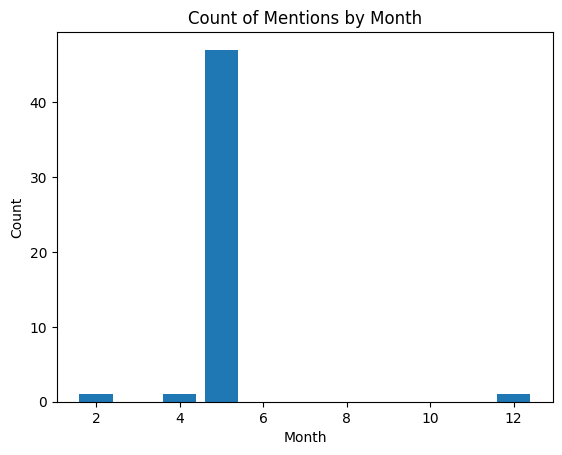

In [19]:
plt.bar(count_months.keys(), count_months.values())
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Count of Mentions by Month')
plt.show()

YOUR WRITTEN RESPONSE HERE


## Implement FAISS vector store

 We’ll now implement a **FAISS-based vector store**, designed for efficient similarity search at scale.

 👉 **Steps**:
 - Use the same sentence transformer model: all-MiniLM-L6-v2.
 - Encode your text into embessings
 - Normalize the vectors.

 FAISS supports multiple similarity types. For cosine similarity, we must:

 ✅ Normalize vectors to unit length  
 ✅ Use `IndexFlatIP` (inner product), because:
 - For normalized vectors, inner product = cosine similarity


In [20]:
# CODE HERE
# Use as many coding cells as you need
encoded_sentence=model.encode(list_strings)
encoded_sentence

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


array([[-0.02673454, -0.0738131 , -0.01063172, ..., -0.06900438,
         0.05050491,  0.0977991 ],
       [-0.04073181, -0.07471912, -0.03514499, ..., -0.14148672,
         0.01633409,  0.06919494],
       [-0.04239139, -0.09101506,  0.00966819, ..., -0.18574603,
        -0.04769478,  0.02522711],
       ...,
       [-0.07604926, -0.05866983, -0.07059098, ..., -0.09694079,
         0.0328295 ,  0.06938581],
       [-0.06938288, -0.01374751, -0.01021106, ..., -0.07465052,
         0.04949504,  0.06318198],
       [-0.01580631,  0.02808019, -0.00805153, ..., -0.11413579,
         0.06226112,  0.04383293]], dtype=float32)

In [21]:
encoded_sentence.shape

(4871, 384)

In [22]:
vector_dimension=encoded_sentence.shape[1]

index = faiss.IndexFlatIP(vector_dimension)
faiss.normalize_L2(encoded_sentence)

We’ll now:
 - Initialize the FAISS index
 - Add the document embeddings

In [23]:
# CODE HERE
# Use as many coding cells as you need
index.add(encoded_sentence)
index

<faiss.swigfaiss_avx512.IndexFlatIP; proxy of <Swig Object of type 'faiss::IndexFlatIP *' at 0x7a74eb83def0> >

### Create a `FaissVectorStore` class with a `.search()` method.

 This method:
 - Encodes and normalizes the query
 - Optionally applies metadata filters
 - Returns top `k` results with similarity scores and metadata

In [24]:
class FaissVectorStore:
    def __init__(self, model=model, embeddings=encoded_sentence, texts=list_strings, metadata=list_dictionaries):
        self.model = model
        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        faiss.normalize_L2(embeddings)
        self.index.add(embeddings)
        self.texts = texts
        self.metadata = metadata

    def search(self, query, k=5, filters=None):
      query_embedding = self.model.encode([query])
      faiss.normalize_L2(query_embedding)
      D, I = self.index.search(query_embedding, k)

      results = []
      for score, idx in zip(D[0], I[0]):
          meta = self.metadata[idx]
          if filters:
              if not all(meta.get(f) == v for f, v in filters.items()):
                  continue
          results.append({
              "text": self.texts[idx],
              "metadata": meta,
              "score": score
          })
      return results

 Let’s run a semantic search using FAISS:
 - Query: `"AI announcement"`
 - Top results: `k=50`

 Print out:
 - Ticker
 - Publication date
 - Provider
 - Cosine similarity score
 - Full text

In [25]:
# CODE HERE
# Use as many coding cells as you need
fais_store=FaissVectorStore()
fais_news=fais_store.search("AI announcement", k=50)
for i in range(len(fais_news)):
  print(f"TICKER: {fais_news[i]['metadata']['TICKER']}")
  print(f"PUBLICATION_DATE: {fais_news[i]['metadata']['PUBLICATION_DATE']}")
  print(f"PROVIDER: {fais_news[i]['metadata']['PROVIDER']}")
  print(f"Similarity score: {fais_news[i]['score']}")
  print(f"Full document text: {fais_news[i]['text']}")
  print()

TICKER: JKHY
PUBLICATION_DATE: 2025-03-17
PROVIDER: Insider Monkey
Similarity score: 0.5604502558708191
Full document text: Jack Henry (JKHY) Integrates AI-Driven Lending Tech With AlgebrikWe recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]

TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Similarity score: 0.5567173361778259
Full document text: AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.

TICKER: PLTR
PUBLICATION_DATE: 2025-05-31
PROVIDER: Motley Fool
Similarity score: 0.5292006731033325
Full document text: Better Arti

## Evaluation: Comparing FAISS Vector Store with your Custom Vector Store

### Retrieval Comparison Across Systems

 👉 **Instructions**:

 - Using the 5 'test_queries' provided in the list below, retrieve the top 5 news for each query using both your custom and FAISS vector stores.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).


In [26]:
test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'

]

In [27]:
# CODE HERE
# Use as many coding cells as you need
for query in test_queries:
  print(f"Query: {query}")
  print("Custom Vector Store:")
  custom_results = store.search(query, k=5)
  for result in custom_results:
    print(f"Ticker: {result[0]['TICKER']}")
    print(f"Publication Date: {result[0]['PUBLICATION_DATE']}")
    print(f"Provider: {result[0]['PROVIDER']}")
    print(f"Similarity Score: {result[1]}")
    print(f"Text: {result[2]}")
    print()
  fais_results = fais_store.search(query, k=5)
  print("FAISS Vector Store:")
  for result in fais_results:
    print(f"Ticker: {result['metadata']['TICKER']}")
    print(f"Publication Date: {result['metadata']['PUBLICATION_DATE']}")
    print(f"Provider: {result['metadata']['PROVIDER']}")
    print(f"Similarity Score: {result['score']}")
    print(f"Text: {result['text']}")
    print()
  print('-------------------------------------------------------------------')

Query: Stock price drop
Custom Vector Store:
Ticker: PKG
Publication Date: 2025-05-29
Provider: StockStory
Similarity Score: 0.6165772080421448
Text: 3 Reasons to Avoid PKG and 1 Stock to Buy InsteadPackaging Corporation of America has gotten torched over the last six months - since November 2024, its stock price has dropped 21.6% to $195 per share. This might have investors contemplating their next move.

Ticker: HUM
Publication Date: 2025-05-27
Provider: StockStory
Similarity Score: 0.5999375581741333
Text: 2 Reasons to Like HUM and 1 to Stay SkepticalHumana has gotten torched over the last six months - since November 2024, its stock price has dropped 24.3% to a new 52-week low of $224.50 per share. This may have investors wondering how to approach the situation.

Ticker: CRL
Publication Date: 2025-05-21
Provider: StockStory
Similarity Score: 0.5679746866226196
Text: Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Trade Down, What You Need To Kn

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: CVX
Publication Date: 2025-05-30
Provider: Fox Business
Similarity Score: 0.5637556314468384
Text: Chevron to layoff approximately 200 employees in Texas in 2025Chevron plans to lay off 200 employees at locations in Midland, Texas as part of a global workforce reduction of up to 20% by 2026.

Ticker: FDX
Publication Date: 2025-05-29
Provider: Sourcing Journal
Similarity Score: 0.5529649257659912
Text: FedEx Plans More Than 300 Layoffs At Texas FacilityThe logistics giant said impacted workers may be offered other positions with the company.

Ticker: CVX
Publication Date: 2025-05-29
Provider: Offshore Technology
Similarity Score: 0.48050662875175476
Text: Chevron to implement around 800 job cuts in TexasChevron previously disclosed plans to lay off 600 California workers starting on 1 June, according to a March report.

Ticker: FDX
Publication Date: 2025-05-23
Provider: FreightWaves
Similarity Score: 0.44033482670783997
Text: Freight industry layoffs surge across California, Tex

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: KEY
Publication Date: 2025-05-31
Provider: Motley Fool
Similarity Score: 0.528187096118927
Text: 2 Large Regional Bank Stocks That Could Get Acquired During the Trump AdministrationMergers and acquisitions (M&A) could pick up in the banking sector under the Trump administration, which plans to deregulate the sector.  Large regional banks could experience consolidation.  The large regional players need to scale if they want to compete with the likes of JPMorgan Chase and Bank of America.

Ticker: STE
Publication Date: 2025-05-21
Provider: Zacks
Similarity Score: 0.517225980758667
Text: AST Business Growth & Strategic Acquisitions Support STERIS StockSTE frequently engages in strategic acquisitions and joint ventures to optimize its portfolio of businesses.

Ticker: COF
Publication Date: 2025-05-27
Provider: Zacks
Similarity Score: 0.4927161633968353
Text: COF Stock Tanks 5.9% Post Discover Merger: A Good Buying Opportunity?COF shares have dipped 5.9% since the Discover deal. Can

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: BK
Publication Date: 2025-05-15
Provider: Financial Times
Similarity Score: 0.3901957869529724
Text: US poised to dial back bank rules imposed in wake of 2008 crisisUS authorities are preparing to announce one of the biggest cuts in banks’ capital requirements for more than a decade, marking the latest sign...

Ticker: NSC
Publication Date: 2025-05-21
Provider: FreightWaves
Similarity Score: 0.34636223316192627
Text: Regulatory risk a red signal to rail mergers, investors toldRailroad executives told an investors conference that future mergers face likely insurmountable regulatory hurdles. The post Regulatory risk a red signal to rail mergers, investors told appeared first on FreightWaves.

Ticker: IT
Publication Date: 2025-05-27
Provider: CFO.com
Similarity Score: 0.3151074945926666
Text: Gartner’s Alex Bant breaks down the new realities of CFO leadershipBant explains how CFOs can make better decisions, challenge the single source of truth, lead under PE, reduce workflow drag 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: PYPL
Publication Date: 2025-05-27
Provider: Zacks
Similarity Score: 0.5430557727813721
Text: 3 Crypto-Centric Stocks in Focus as Bitcoin Resumes Its RallyBitcoin hovers near $110K as crypto sentiment surges. V, PYPL, and CLSK emerge as top stock picks with rising earnings outlooks.

Ticker: COIN
Publication Date: 2025-05-28
Provider: Investor's Business Daily
Similarity Score: 0.5030361413955688
Text: Cryptocurrency Prices And News: Bitcoin Hovers Near Record High, Miners Join RallyCryptocurrency News:  Cryptocurrency prices have been mixed this week after bitcoin surged to a new record high on May 22.  Bitcoin traded around $107,500 on Wednesday, modestly retreating new peak of $111,970 on Thursday according to CoinMarketCap data.  LMAX analyst Joel Kruger recently told IBD that the fresh high could set the stage for a measured rally toward $145,000.

Ticker: COIN
Publication Date: 2025-05-28
Provider: Barrons.com
Similarity Score: 0.42872631549835205
Text: Bitcoin Price Falls

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


### **Q3.** Do you observe any significant differences in the top-5 retrieved results for each query between the two systems? Explain why these differences may or may not occur.

YOUR WRITTEN RESPONSE HERE


## Evaluation: Comparing 2 embedding models with your Custom Vector Store

 👉 **Instructions**:

 - Implement your custom vector store with `'all-MiniLM-L6-v2'` model from `sentence-transformers`, and compare it with the `'all-mpnet-base-v2'` model from `sentence-transformers`.
 - Similarly, retrieve the top 5 news for each query using both implementations.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).

In [28]:
# CODE HERE
# Use as many coding cells as you need
model_mpnet=SentenceTransformer('all-mpnet-base-v2')
store_mpnet=CustomVectorStore(model_mpnet)

for query in test_queries:
  print(f"Query: {query}")
  print("Custom Vector Store:")
  custom_results = store.search(query, k=5)
  for result in custom_results:
    print(f"Ticker: {result[0]['TICKER']}")
    print(f"Publication Date: {result[0]['PUBLICATION_DATE']}")
    print(f"Provider: {result[0]['PROVIDER']}")
    print(f"Similarity Score: {result[1]}")
    print(f"Text: {result[2]}")
    print()
  mpnet_results = store_mpnet.search(query, k=5)
  print("MPNET Vector Store:")
  for result in mpnet_results:
    print(f"Ticker: {result[0]['TICKER']}")
    print(f"Publication Date: {result[0]['PUBLICATION_DATE']}")
    print(f"Provider: {result[0]['PROVIDER']}")
    print(f"Similarity Score: {result[1]}")
    print(f"Text: {result[2]}")
    print()
  print('-------------------------------------------------------------------')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

Ticker: KEY
Publication Date: 2025-05-31
Provider: Motley Fool
Similarity Score: 0.528187096118927
Text: 2 Large Regional Bank Stocks That Could Get Acquired During the Trump AdministrationMergers and acquisitions (M&A) could pick up in the banking sector under the Trump administration, which plans to deregulate the sector.  Large regional banks could experience consolidation.  The large regional players need to scale if they want to compete with the likes of JPMorgan Chase and Bank of America.

Ticker: STE
Publication Date: 2025-05-21
Provider: Zacks
Similarity Score: 0.517225980758667
Text: AST Business Growth & Strategic Acquisitions Support STERIS StockSTE frequently engages in strategic acquisitions and joint ventures to optimize its portfolio of businesses.

Ticker: COF
Publication Date: 2025-05-27
Provider: Zacks
Similarity Score: 0.4927161633968353
Text: COF Stock Tanks 5.9% Post Discover Merger: A Good Buying Opportunity?COF shares have dipped 5.9% since the Discover deal. Can

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: BK
Publication Date: 2025-05-15
Provider: Financial Times
Similarity Score: 0.3901957869529724
Text: US poised to dial back bank rules imposed in wake of 2008 crisisUS authorities are preparing to announce one of the biggest cuts in banks’ capital requirements for more than a decade, marking the latest sign...

Ticker: NSC
Publication Date: 2025-05-21
Provider: FreightWaves
Similarity Score: 0.34636223316192627
Text: Regulatory risk a red signal to rail mergers, investors toldRailroad executives told an investors conference that future mergers face likely insurmountable regulatory hurdles. The post Regulatory risk a red signal to rail mergers, investors told appeared first on FreightWaves.

Ticker: IT
Publication Date: 2025-05-27
Provider: CFO.com
Similarity Score: 0.3151074945926666
Text: Gartner’s Alex Bant breaks down the new realities of CFO leadershipBant explains how CFOs can make better decisions, challenge the single source of truth, lead under PE, reduce workflow drag 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Ticker: PYPL
Publication Date: 2025-05-27
Provider: Zacks
Similarity Score: 0.5430557727813721
Text: 3 Crypto-Centric Stocks in Focus as Bitcoin Resumes Its RallyBitcoin hovers near $110K as crypto sentiment surges. V, PYPL, and CLSK emerge as top stock picks with rising earnings outlooks.

Ticker: COIN
Publication Date: 2025-05-28
Provider: Investor's Business Daily
Similarity Score: 0.5030361413955688
Text: Cryptocurrency Prices And News: Bitcoin Hovers Near Record High, Miners Join RallyCryptocurrency News:  Cryptocurrency prices have been mixed this week after bitcoin surged to a new record high on May 22.  Bitcoin traded around $107,500 on Wednesday, modestly retreating new peak of $111,970 on Thursday according to CoinMarketCap data.  LMAX analyst Joel Kruger recently told IBD that the fresh high could set the stage for a measured rally toward $145,000.

Ticker: COIN
Publication Date: 2025-05-28
Provider: Barrons.com
Similarity Score: 0.42872631549835205
Text: Bitcoin Price Falls

### **Q4.**  Which embedding model performs better in retrieving relevant documents for the queries? Support your answer with specific examples from the results.

I think that the MPNET is better, this cause it makes a much better semantic separation, even if the similarity score it could be more penalized, I think it has a better performance.

For example, with the mergers & acquisitions, the news are much more realeted to the query than the CVS, and also the smimilarity score is higher than the other one. Other example was with the FED interest rate, the CVS has higher similarities, but the second news I think it isn´t related to the query, for both cases. But when it did the MPNET, the socre is almost 0, which means it was more penalized than the CVS.

## 🛠️ Implementation-Level Questions

### **Q5.**  What role does vector normalization play in each implementation?

As far as I understood, the normalization is used to have normal distribution in the vectors, this helps making a clear semantic separation. This helps to the algorithm to distnguish better the different news and make clusters more distant form each other.


### **Q6.**  What would happen if vectors were not normalized before indexing?

The performance of the algorithm is slower, the similairty score could be higher and that can cause wrong nformation, the clusters could be near each other generating a bad calsification, among other negative results.


## 🧠 Critical Thinking / Design Choices


### **Q7.** Which implementation would you choose for a production-scale search system? Why?


I have to investigate more, but I think that the best option is MPNET. The main reason is because the normalization helps to have a more clear semantic separation regarding the different topics.




### **Q8.**   If your dataset grows from 5K to 5M articles, which implementation will scale better? Justify your answer.

For my perspective, the main thing here is on how you embedd the text, cause that's the core of the vector databases. I think that I stay with all-mpnet-base-v2, it has a better semantic separation and the preformance is much way better with a GPU. I ran with both, CPU and GPU; with the first it had a duration of more than 1 hour, and with GPU it was really fast.